# Telco Customer Churn — Predictive Retention Analysis
## Notebook 04 · ML Training + Evaluation + XAI + Business Impact

| | |
|---|---|
| **Author** | Natalia Stekolnikova |
| **Course** | IFCT153PO — Big Data & Business Intelligence |
| **Input** | `outputs/telco_model_ready.csv` · `outputs/telco_clean.csv` |
| **Output** | plots p08–p13 · business impact report |

---

### What this notebook does

```
1. EDA           — visual exploration of churn patterns
2. Baseline      — dummy model to contextualise all metrics
3. Split         — 80/20 stratified train/test (same for all models)
4. Train         — Logistic Regression + Random Forest + Gradient Boosting
5. Evaluate      — ALL metrics: Accuracy, AUC-ROC, Recall, Precision, F1, CV AUC
6. Visualise     — Confusion Matrices + ROC Curves
7. XAI           — Feature Importance (all three models compared)
8. Select        — model selection based on full metric picture
9. Business      — ROI calculation and retention strategy
10. Conclusions  — data-driven, based on cross-model feature consistency
```

---

### Metrics strategy — all six metrics reported

No single metric tells the complete story. All six are reported together
and read as a system:

| Metric | What it measures | Why it matters here |
|---|---|---|
| **Accuracy** | % of all correct predictions | General correctness — context metric |
| **AUC-ROC** | Separability at all thresholds | Overall model quality, imbalance-robust |
| **Recall** | % of real churners found | Minimise missed churners (FN costs most) |
| **Precision** | % of predicted churners that are real | Campaign efficiency — essential under imbalance |
| **F1-score** | Harmonic mean of Recall and Precision | Penalises extreme imbalance between the two |
| **CV AUC** | Stability across 5 data splits | Model is robust, not overfitting |

### Class imbalance — why it affects every metric

**5,174 retained (73.5%)  vs  1,869 churned (26.5%)** — ratio 2.77:1

Under this imbalance:
- **Accuracy** can be high even for a useless model (dummy achieves 73.5%)
- **Recall** tends to be low if imbalance is not handled
- **Precision** becomes critical — many false positives waste retention budget
- **F1** better reflects true performance than Accuracy alone
- **Precision-Recall trade-off** is explicit and must be managed

All three models use balanced class weights to compensate for the 2.77:1 imbalance.

### Three models — why compare?

| Model | Type | Imbalance handling |
|---|---|---|
| **Logistic Regression** | Linear | `class_weight='balanced'` |
| **Random Forest** | Ensemble — parallel trees | `class_weight='balanced'` |
| **Gradient Boosting** | Ensemble — sequential boosting | `sample_weight` via `compute_sample_weight` |

---
## 0 · Environment

In [3]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection    import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model       import LogisticRegression
from sklearn.ensemble           import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing      import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics            import (
    accuracy_score, roc_auc_score, recall_score,
    precision_score, f1_score,
    confusion_matrix, roc_curve
)

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams.update({
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.titlesize'   : 12,
    'axes.titleweight' : 'bold',
    'font.size'        : 10,
})

C_CHURN  = '#e74c3c'
C_STAY   = '#2ecc71'
C_BLUE   = '#3498db'
C_ORANGE = '#e67e22'
C_PURPLE = '#9b59b6'
C_GREY   = '#95a5a6'

MODEL_COLORS = {
    'Logistic Regression': C_BLUE,
    'Random Forest'      : C_ORANGE,
    'Gradient Boosting'  : C_PURPLE,
}

NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR.parent / 'data').exists() \
               else NOTEBOOK_DIR
OUTPUT_DIR = PROJECT_ROOT / 'outputs'

MODEL_CSV = OUTPUT_DIR / 'telco_model_ready.csv'
CLEAN_CSV = OUTPUT_DIR / 'telco_clean.csv'

assert MODEL_CSV.exists(), f'Run Notebook 02 first: {MODEL_CSV}'
assert CLEAN_CSV.exists(), f'Run Notebook 02 first: {CLEAN_CSV}'

print('Environment ready.')
print(f'  Model CSV : {MODEL_CSV}')
print(f'  Clean CSV : {CLEAN_CSV}')

Environment ready.
  Model CSV : C:\Users\natal\Documents\churn_project\outputs\telco_model_ready.csv
  Clean CSV : C:\Users\natal\Documents\churn_project\outputs\telco_clean.csv


---
## 1 · Load data

In [5]:
df_model = pd.read_csv(MODEL_CSV)
df_clean = pd.read_csv(CLEAN_CSV)

if 'NumServices' not in df_clean.columns:
    svc = ['OnlineSecurity','OnlineBackup','DeviceProtection',
           'TechSupport','StreamingTV','StreamingMovies']
    df_clean['NumServices'] = (
        (df_clean['PhoneService']    == 'Yes').astype(int) +
        (df_clean['MultipleLines']   == 'Yes').astype(int) +
        (df_clean['InternetService'] != 'No' ).astype(int) +
        sum((df_clean[c] == 'Yes').astype(int) for c in svc)
    )
if 'TenureGroup' not in df_clean.columns:
    df_clean['TenureGroup'] = pd.cut(
        df_clean['tenure'], bins=[0,12,24,48,72],
        labels=['New','Junior','Mid','Loyal'],
        include_lowest=True
    ).astype(str)

n0 = (df_model['Churn']==0).sum()
n1 = (df_model['Churn']==1).sum()

print(f'Model data : {df_model.shape[0]:,} rows × {df_model.shape[1]} columns')
print(f'Clean data : {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')
print()
print(f'Churn=0 (retained) : {n0:,}  ({n0/len(df_model)*100:.1f}%)')
print(f'Churn=1 (churned)  : {n1:,}  ({n1/len(df_model)*100:.1f}%)')
print(f'Imbalance ratio    : {n0/n1:.2f}:1')
print()
print('Feature set (23 features — from telco_model_ready.csv):')
features = [c for c in df_model.columns if c != 'Churn']
for f in features:
    tag = '  ← engineered' if f == 'NumServices' else ''
    print(f'  {f}{tag}')

Model data : 7,043 rows × 24 columns
Clean data : 7,043 rows × 24 columns

Churn=0 (retained) : 5,174  (73.5%)
Churn=1 (churned)  : 1,869  (26.5%)
Imbalance ratio    : 2.77:1

Feature set (23 features — from telco_model_ready.csv):
  gender
  SeniorCitizen
  Partner
  Dependents
  tenure
  PhoneService
  MultipleLines
  OnlineSecurity
  OnlineBackup
  DeviceProtection
  TechSupport
  StreamingTV
  StreamingMovies
  Contract
  PaperlessBilling
  MonthlyCharges
  TotalCharges
  NumServices  ← engineered
  InternetService_DSL
  InternetService_Fiber optic
  PaymentMethod_Credit card (automatic)
  PaymentMethod_Electronic check
  PaymentMethod_Mailed check


---
## 2 · EDA — Visual exploration of churn patterns

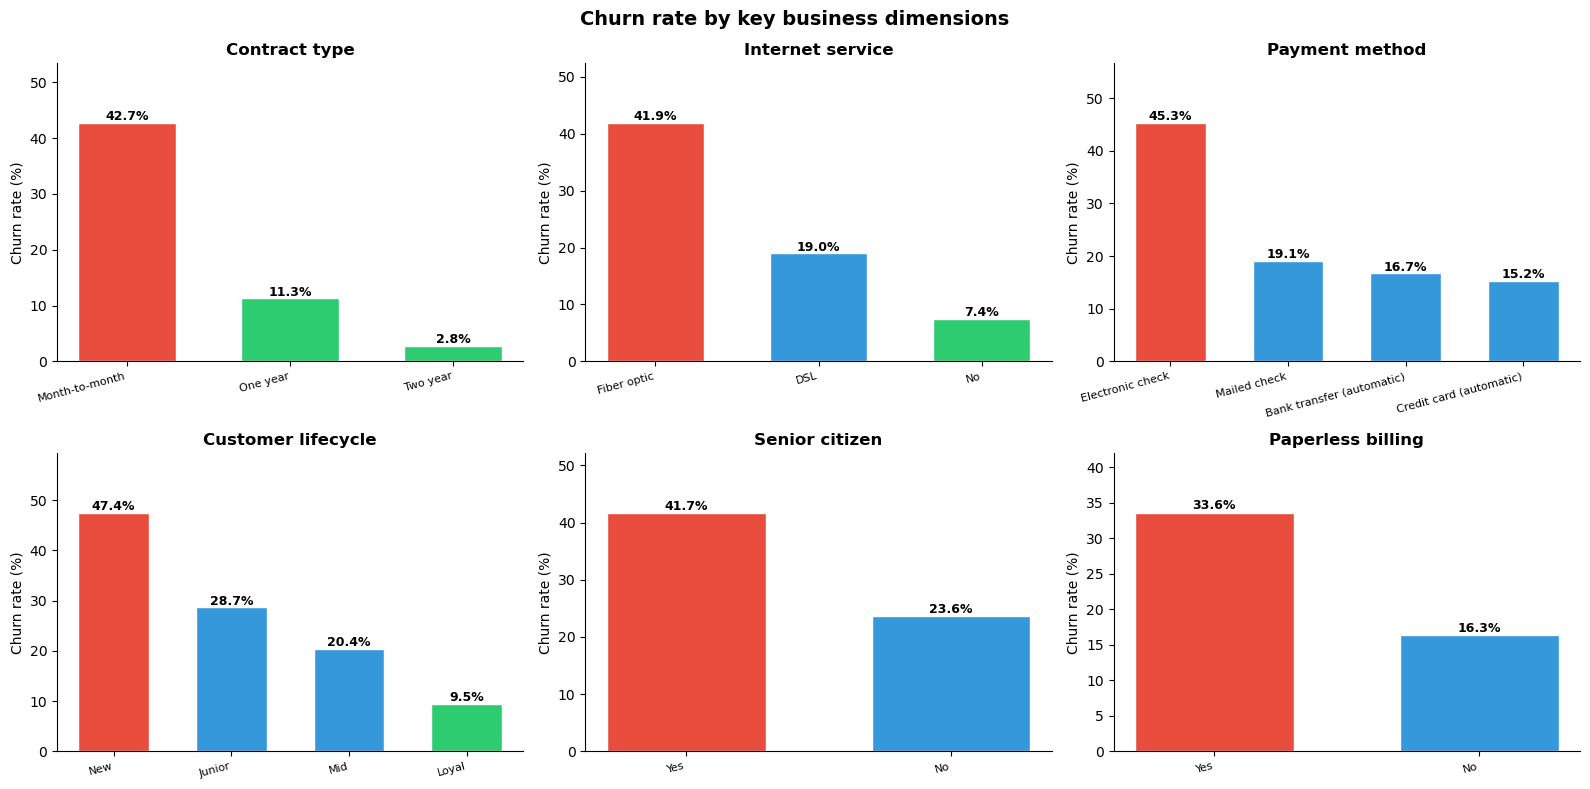

Saved: p08_eda_categorical.png


In [55]:
cat_features = [
    ('Contract',        'Contract type'),
    ('InternetService', 'Internet service'),
    ('PaymentMethod',   'Payment method'),
    ('TenureGroup',     'Customer lifecycle'),
    ('SeniorCitizen',   'Senior citizen'),
    ('PaperlessBilling','Paperless billing'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, (col, title) in zip(axes.flat, cat_features):
    cr = (df_clean.groupby(col)['Churn']
          .mean().mul(100).sort_values(ascending=False))
    colors = [C_CHURN if v > 30 else C_BLUE if v > 15 else C_STAY
              for v in cr.values]
    bars = ax.bar(range(len(cr)), cr.values,
                  color=colors, edgecolor='white', width=0.6)
    for bar, val in zip(bars, cr.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(title)
    ax.set_ylabel('Churn rate (%)')
    ax.set_xticks(range(len(cr)))
    ax.set_xticklabels(cr.index, rotation=15, ha='right', fontsize=8)
    ax.set_ylim(0, max(cr.values) * 1.25)

plt.suptitle('Churn rate by key business dimensions',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'p08_eda_categorical.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: p08_eda_categorical.png')

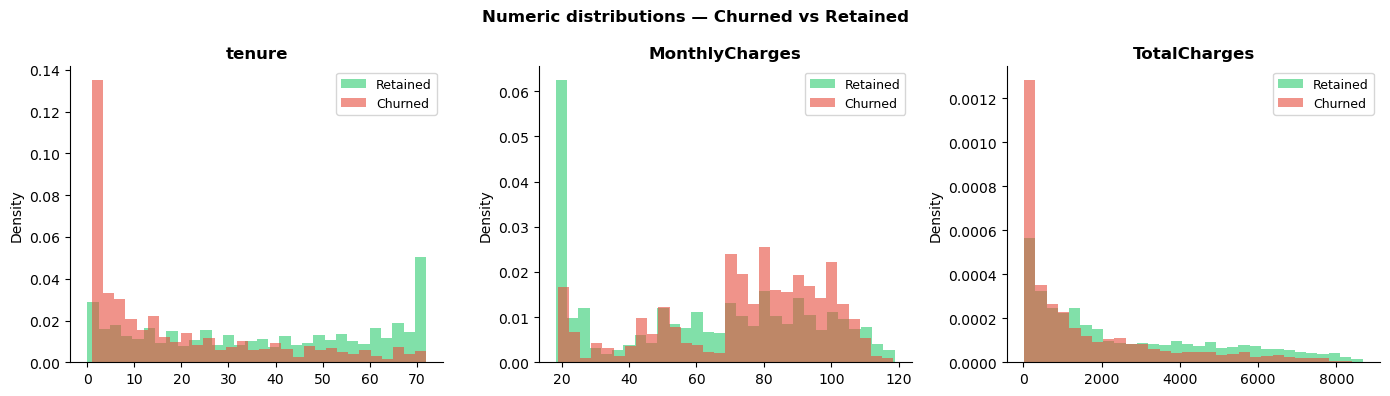

,tenure,MonthlyCharges,TotalCharges
Churn,,,
Retained,37.5700,61.2700,2550.0000
Churned,17.9800,74.4400,1531.8000



MonthlyCharges: churned pay MORE   (+€13) — financial pressure
TotalCharges  : churned paid LESS  (-€1,018) — shorter tenure, not yet loyal
Opposite signs = two different business dimensions, not a contradiction.
Saved: p09_eda_numeric.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    for v, color, label in [(0, C_STAY,'Retained'),(1, C_CHURN,'Churned')]:
        ax.hist(df_clean[df_clean['Churn']==v][col].dropna(),
                bins=30, alpha=0.6, color=color,
                label=label, density=True)
    ax.set_title(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Numeric distributions — Churned vs Retained',
             fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'p09_eda_numeric.png', dpi=150)
plt.show()

stats = (df_clean.groupby('Churn')
         [['tenure','MonthlyCharges','TotalCharges']]
         .mean().round(2))
stats.index = stats.index.map({0:'Retained', 1:'Churned'})
display(stats)
print()
print('MonthlyCharges: churned pay MORE   (+€13) — financial pressure')
print('TotalCharges  : churned paid LESS  (-€1,018) — shorter tenure, not yet loyal')
print('Opposite signs = two different business dimensions, not a contradiction.')
print('Saved: p09_eda_numeric.png')

---
## 3 · Baseline model

Before training any real model we establish a dummy baseline
that always predicts 0 (no churn). Its metrics contextualise
what our models must beat — and reveal why Accuracy alone is insufficient.

In [10]:
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

dummy_pred  = np.zeros(len(y), dtype=int)
dummy_proba = np.zeros(len(y), dtype=float)

print('DUMMY BASELINE — always predict 0 (no churn), no data analysis:')
print()
print(f'  Accuracy  : {accuracy_score(y, dummy_pred)*100:.1f}%')
print(f'  AUC-ROC   : {roc_auc_score(y, dummy_proba):.4f}')
print(f'  Recall    : {recall_score(y, dummy_pred):.4f}')
print(f'  Precision : {precision_score(y, dummy_pred, zero_division=0):.4f}')
print(f'  F1-score  : {f1_score(y, dummy_pred):.4f}')
print()
print('Reading the baseline together:')
print('  Accuracy=73.5% looks reasonable — but Recall=0 means zero churners found.')
print('  AUC=0.500 = random coin flip. F1=0. Precision=0.')
print('  A model with 73.5% Accuracy and Recall=0 is completely useless.')
print()
print('This demonstrates why ALL six metrics must be read together.')
print('Accuracy alone would incorrectly suggest this model is acceptable.')
print()
print('Under class imbalance 2.77:1, Precision is especially important:')
print('  High false positive rate = wasted retention budget')
print('  Precision shows how efficient each retention call is')
print()
fn_cost = df_clean[df_clean['Churn']==1]['TotalCharges'].mean()
fp_cost = 15
print(f'  FN cost (missed churner)  : €{fn_cost:,.2f} avg LTV lost')
print(f'  FP cost (false alarm)     : €{fp_cost:.2f} retention call')
print(f'  Cost ratio                : {fn_cost/fp_cost:.0f}× — '
      f'FN is {fn_cost/fp_cost:.0f}× more costly than FP')

DUMMY BASELINE — always predict 0 (no churn), no data analysis:

  Accuracy  : 73.5%
  AUC-ROC   : 0.5000
  Recall    : 0.0000
  Precision : 0.0000
  F1-score  : 0.0000

Reading the baseline together:
  Accuracy=73.5% looks reasonable — but Recall=0 means zero churners found.
  AUC=0.500 = random coin flip. F1=0. Precision=0.
  A model with 73.5% Accuracy and Recall=0 is completely useless.

This demonstrates why ALL six metrics must be read together.
Accuracy alone would incorrectly suggest this model is acceptable.

Under class imbalance 2.77:1, Precision is especially important:
  High false positive rate = wasted retention budget
  Precision shows how efficient each retention call is

  FN cost (missed churner)  : €1,531.80 avg LTV lost
  FP cost (false alarm)     : €15.00 retention call
  Cost ratio                : 102× — FN is 102× more costly than FP


---
## 4 · Train / Test split

All three models use the **identical** split — the only fair way to compare.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Total   : {len(X):,} customers')
print(f'Train   : {len(X_train):,}  ({len(X_train)/len(X)*100:.0f}%)  '
      f'churn={y_train.mean()*100:.1f}%')
print(f'Test    : {len(X_test):,}   ({len(X_test)/len(X)*100:.0f}%)  '
      f'churn={y_test.mean()*100:.1f}%')
print()
print('stratify=y confirmed: both sets preserve 26.5% churn rate.')
print()

# StandardScaler for Logistic Regression only
# LR is distance-based — large-scale features dominate without scaling
# RF and GB are threshold-based (trees) — scale-invariant
# fit_transform on TRAIN only — prevents data leakage to test
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('StandardScaler fitted on X_train only (no leakage).')
print('  For: Logistic Regression (distance-based)')
print('  Not for: Random Forest, Gradient Boosting (threshold-based)')

Total   : 7,043 customers
Train   : 5,634  (80%)  churn=26.5%
Test    : 1,409   (20%)  churn=26.5%

stratify=y confirmed: both sets preserve 26.5% churn rate.

StandardScaler fitted on X_train only (no leakage).
  For: Logistic Regression (distance-based)
  Not for: Random Forest, Gradient Boosting (threshold-based)


---
## 5 · Train all three models

**Class imbalance handling — 2.77:1 ratio:**

LR + RF use `class_weight='balanced'` — sklearn computes:
```
weight[0] = 7043 / (2 × 5174) = 0.680   weight[1] = 7043 / (2 × 1869) = 1.884
```
Errors on churned customers penalised 2.77× more.

GB does not support `class_weight` — uses `sample_weight` via
`compute_sample_weight('balanced', y_train)` — mathematically identical effect.

In [71]:
# ── Logistic Regression ───────────────────────────────────────
lr = LogisticRegression(
    class_weight='balanced', random_state=42, max_iter=1000
)
lr.fit(X_train_sc, y_train)
lr_proba = lr.predict_proba(X_test_sc)[:, 1]
lr_pred  = lr.predict(X_test_sc)
cv_lr    = cross_val_score(
    lr, X_train_sc, y_train,
    cv=StratifiedKFold(5), scoring='roc_auc'
)
print('Logistic Regression  trained ✓')
print(f'  class_weight=balanced  '
      f'w[0]={7043/(2*5174):.3f}  w[1]={7043/(2*1869):.3f}')
print()

# ── Random Forest ─────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=100, class_weight='balanced',
    random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_pred  = rf.predict(X_test)
cv_rf    = cross_val_score(
    rf, X_train, y_train,
    cv=StratifiedKFold(5), scoring='roc_auc'
)
print('Random Forest        trained ✓')
print(f'  100 parallel trees  class_weight=balanced  n_jobs=-1')
print()

# ── Gradient Boosting ─────────────────────────────────────────
# GradientBoostingClassifier does NOT support class_weight parameter
# Solution: compute_sample_weight — identical mathematical effect
sample_weights = compute_sample_weight('balanced', y_train)

gb = GradientBoostingClassifier(
    n_estimators=200, max_depth=4,
    learning_rate=0.05, subsample=0.8,
    random_state=42
)
gb.fit(X_train, y_train, sample_weight=sample_weights)
gb_proba = gb.predict_proba(X_test)[:, 1]
gb_pred  = gb.predict(X_test)
cv_gb    = cross_val_score(
    gb, X_train, y_train,
    cv=StratifiedKFold(5), scoring='roc_auc'
)
print('Gradient Boosting    trained ✓')
print(f'  200 sequential trees  lr=0.05  max_depth=4')
print(f'  sample_weight=balanced (= class_weight equivalent)')
print()

# Store all models for iteration
all_models = [
    ('Logistic Regression', lr_proba, lr_pred, cv_lr),
    ('Random Forest',       rf_proba, rf_pred, cv_rf),
    ('Gradient Boosting',   gb_proba, gb_pred, cv_gb),
]
print('All three models trained on identical X_train / y_train.')
print('All three will be evaluated on identical X_test / y_test.')

Logistic Regression  trained ✓
  class_weight=balanced  w[0]=0.681  w[1]=1.884

Random Forest        trained ✓
  100 parallel trees  class_weight=balanced  n_jobs=-1

Gradient Boosting    trained ✓
  200 sequential trees  lr=0.05  max_depth=4
  sample_weight=balanced (= class_weight equivalent)

All three models trained on identical X_train / y_train.
All three will be evaluated on identical X_test / y_test.


---
## 6 · Evaluation — ALL six metrics

All six metrics are reported for every model including the dummy baseline.
No metric is excluded — each reveals a different aspect of model behaviour.
Under class imbalance, **Precision is mandatory** because high FP rates
waste the retention budget.

In [75]:
# ── Collect all metrics ───────────────────────────────────────
metrics_data = {}

# Dummy baseline
dummy_pred_te  = np.zeros(len(y_test), dtype=int)
dummy_proba_te = np.zeros(len(y_test), dtype=float)
metrics_data['⚠ Dummy baseline'] = {
    'Accuracy'     : round(accuracy_score(y_test, dummy_pred_te),             4),
    'AUC-ROC'      : round(roc_auc_score(y_test, dummy_proba_te),             4),
    'Recall'       : round(recall_score(y_test, dummy_pred_te),               4),
    'Precision'    : round(precision_score(y_test, dummy_pred_te,
                                           zero_division=0),                  4),
    'F1-score'     : round(f1_score(y_test, dummy_pred_te),                   4),
    'CV AUC (mean)': 0.5000,
    'CV AUC (std)' : 0.0000,
    'TP': 0,
    'FP': 0,
    'FN': int(y_test.sum()),
    'TN': int((y_test == 0).sum()),
}

# Three models
for name, proba, pred, cv in all_models:
    tn_i, fp_i, fn_i, tp_i = confusion_matrix(y_test, pred).ravel()
    metrics_data[name] = {
        'Accuracy'     : round(accuracy_score(y_test, pred),    4),
        'AUC-ROC'      : round(roc_auc_score(y_test, proba),    4),
        'Recall'       : round(recall_score(y_test, pred),      4),
        'Precision'    : round(precision_score(y_test, pred),   4),
        'F1-score'     : round(f1_score(y_test, pred),          4),
        'CV AUC (mean)': round(cv.mean(),                       4),
        'CV AUC (std)' : round(cv.std(),                        4),
        'TP': int(tp_i), 'FP': int(fp_i),
        'FN': int(fn_i), 'TN': int(tn_i),
    }

metrics_df = pd.DataFrame(metrics_data).T
ALL_METRIC_COLS = ['Accuracy','AUC-ROC','Recall',
                   'Precision','F1-score',
                   'CV AUC (mean)','CV AUC (std)']

print('Performance — ALL metrics — Dummy baseline + three models:')
print()
display(metrics_df[ALL_METRIC_COLS])
print()

# ── What each metric reveals ──────────────────────────────────
print('═' * 65)
print('WHAT EACH METRIC REVEALS')
print('═' * 65)
print()

dm  = metrics_data['⚠ Dummy baseline']
lrm = metrics_data['Logistic Regression']
rfm = metrics_data['Random Forest']
gbm = metrics_data['Gradient Boosting']

print('ACCURACY = (TP+TN) / all')
print('  Overall correctness as % of all predictions.')
print(f'  Dummy={dm["Accuracy"]:.4f}  LR={lrm["Accuracy"]:.4f}  '
      f'RF={rfm["Accuracy"]:.4f}  GB={gbm["Accuracy"]:.4f}')
print(f'  RF has highest Accuracy — but its Recall is lowest.')
print(f'  Dummy achieves {dm["Accuracy"]*100:.1f}% — context for the other values.')
print()

print('AUC-ROC = area under ROC curve (all thresholds)')
print('  Best overall separability measure — robust to class imbalance.')
print(f'  Dummy={dm["AUC-ROC"]:.4f}  LR={lrm["AUC-ROC"]:.4f}  '
      f'RF={rfm["AUC-ROC"]:.4f}  GB={gbm["AUC-ROC"]:.4f}')
print(f'  GB and LR are very close. All three >> 0.500 baseline.')
print()

print('RECALL = TP / (TP+FN)  — "how many real churners did we find?"')
print('  Critical: FN (missed churner) = avg LTV €1,532 lost forever.')
print(f'  Dummy={dm["Recall"]:.4f}  LR={lrm["Recall"]:.4f}  '
      f'RF={rfm["Recall"]:.4f}  GB={gbm["Recall"]:.4f}')
tp_lr = lrm['TP']; tp_rf = rfm['TP']
print(f'  LR finds {tp_lr} churners vs RF finds {tp_rf} — '
      f'difference of {tp_lr-tp_rf} × €1,532 = €{(tp_lr-tp_rf)*1532:,}')
print()

print('PRECISION = TP / (TP+FP)  — "how accurate are our alarms?"')
print('  Critical under imbalance: FP (false alarm) = wasted retention call.')
print(f'  Dummy={dm["Precision"]:.4f}  LR={lrm["Precision"]:.4f}  '
      f'RF={rfm["Precision"]:.4f}  GB={gbm["Precision"]:.4f}')
print(f'  LR: {lrm["FP"]} false alarms × €15 = €{lrm["FP"]*15:,}')
print(f'  RF: {rfm["FP"]} false alarms × €15 = €{rfm["FP"]*15:,}')
print(f'  RF wastes less budget on false alarms — but misses far more churners.')
print()

print('F1-SCORE = 2 × (Precision × Recall) / (Precision + Recall)')
print('  Harmonic mean — penalises extreme imbalance between Prec and Recall.')
print('  Better than Accuracy under class imbalance.')
print(f'  Dummy={dm["F1-score"]:.4f}  LR={lrm["F1-score"]:.4f}  '
      f'RF={rfm["F1-score"]:.4f}  GB={gbm["F1-score"]:.4f}')
print(f'  LR and GB both outperform RF. LR best overall F1.')
print()

print('CV AUC = AUC averaged across 5 stratified splits')
print('  Measures stability — is the model robust or did it get a lucky split?')
print(f'  LR={lrm["CV AUC (mean)"]:.4f}±{lrm["CV AUC (std)"]:.4f}  '
      f'RF={rfm["CV AUC (mean)"]:.4f}±{rfm["CV AUC (std)"]:.4f}  '
      f'GB={gbm["CV AUC (mean)"]:.4f}±{gbm["CV AUC (std)"]:.4f}')
print(f'  All three stable — CV AUC ≈ test AUC, low std < 0.015.')
print()

print('═' * 65)
print('PRECISION-RECALL TRADE-OFF UNDER 2.77:1 IMBALANCE')
print('═' * 65)
print()
print(f'  LR : Recall={lrm["Recall"]:.4f}  Precision={lrm["Precision"]:.4f}')
print(f'       Finds more churners — more false alarms per correct prediction')
print(f'  RF : Recall={rfm["Recall"]:.4f}  Precision={rfm["Precision"]:.4f}')
print(f'       Fewer false alarms — but misses many churners')
print(f'  GB : Recall={gbm["Recall"]:.4f}  Precision={gbm["Precision"]:.4f}')
print(f'       Balanced — between LR and RF')
print()
print('  This trade-off is inherent in all classifiers.')
print('  Higher Recall → lower Precision (calls more people, more false alarms).')
print('  Higher Precision → lower Recall (selective, misses more churners).')
print()
print('  Business resolution: FN costs 102× more than FP')
print('  → Recall takes priority when AUC is similar across models.')

Performance — ALL metrics — Dummy baseline + three models:



,Accuracy,AUC-ROC,Recall,Precision,F1-score,CV AUC (mean),CV AUC (std)
⚠ Dummy baseline,0.7346,0.5000,0.0000,0.0000,0.0000,0.5000,0.0000
Logistic Regression,0.7388,0.8416,0.7834,0.5052,0.6143,0.8456,0.0139
Random Forest,0.7857,0.8278,0.4813,0.6250,0.5438,0.8220,0.0114
Gradient Boosting,0.7523,0.8431,0.7647,0.5229,0.6211,0.8453,0.0120



═════════════════════════════════════════════════════════════════
WHAT EACH METRIC REVEALS
═════════════════════════════════════════════════════════════════

ACCURACY = (TP+TN) / all
  Overall correctness as % of all predictions.
  Dummy=0.7346  LR=0.7388  RF=0.7857  GB=0.7523
  RF has highest Accuracy — but its Recall is lowest.
  Dummy achieves 73.5% — context for the other values.

AUC-ROC = area under ROC curve (all thresholds)
  Best overall separability measure — robust to class imbalance.
  Dummy=0.5000  LR=0.8416  RF=0.8278  GB=0.8431
  GB and LR are very close. All three >> 0.500 baseline.

RECALL = TP / (TP+FN)  — "how many real churners did we find?"
  Critical: FN (missed churner) = avg LTV €1,532 lost forever.
  Dummy=0.0000  LR=0.7834  RF=0.4813  GB=0.7647
  LR finds 293 churners vs RF finds 180 — difference of 113 × €1,532 = €173,116

PRECISION = TP / (TP+FP)  — "how accurate are our alarms?"
  Critical under imbalance: FP (false alarm) = wasted retention call.
  Dummy=

---
## 7 · Confusion matrices — all three models

Confusion matrix details with financial impact:


,TP,FP,FN,TN,Recall %,Precision %,FN cost (€),FP cost (€)
Logistic Regression,293,287,81,748,78.3000,50.5000,124092,4305
Random Forest,180,108,194,927,48.1000,62.5000,297208,1620
Gradient Boosting,286,261,88,774,76.5000,52.3000,134816,3915



Total churners in test set: 374



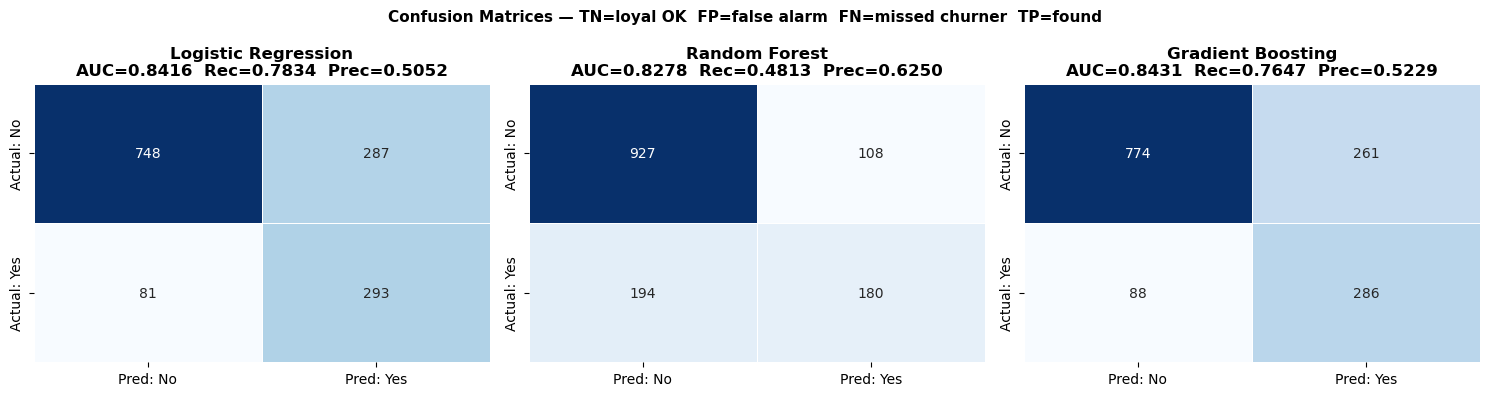

Saved: p10_confusion_matrices.png


In [77]:
# ── Confusion matrix details ──────────────────────────────────
print('Confusion matrix details with financial impact:')
cm_df = metrics_df[['TP','FP','FN','TN']].astype(int).drop(
    index=['⚠ Dummy baseline'])
cm_df['Recall %']    = (cm_df['TP']/(cm_df['TP']+cm_df['FN'])*100).round(1)
cm_df['Precision %'] = (cm_df['TP']/(cm_df['TP']+cm_df['FP'])*100).round(1)
cm_df['FN cost (€)'] = cm_df['FN'] * 1532
cm_df['FP cost (€)'] = cm_df['FP'] * 15
display(cm_df)
print()
print(f'Total churners in test set: {int(y_test.sum())}')
print()

# ── Side-by-side heatmaps ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, proba, pred, _) in zip(axes, all_models):
    cm_i = confusion_matrix(y_test, pred)
    tn_i, fp_i, fn_i, tp_i = cm_i.ravel()
    sns.heatmap(
        cm_i, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Pred: No','Pred: Yes'],
        yticklabels=['Actual: No','Actual: Yes'],
        ax=ax, linewidths=0.5, cbar=False
    )
    auc = roc_auc_score(y_test, proba)
    rec = recall_score(y_test, pred)
    prec = precision_score(y_test, pred)
    ax.set_title(
        f'{name}\n'
        f'AUC={auc:.4f}  Rec={rec:.4f}  Prec={prec:.4f}'
    )

plt.suptitle(
    'Confusion Matrices — TN=loyal OK  FP=false alarm  FN=missed churner  TP=found',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'p10_confusion_matrices.png', dpi=150)
plt.show()
print('Saved: p10_confusion_matrices.png')

---
## 8 · ROC curves — all three models

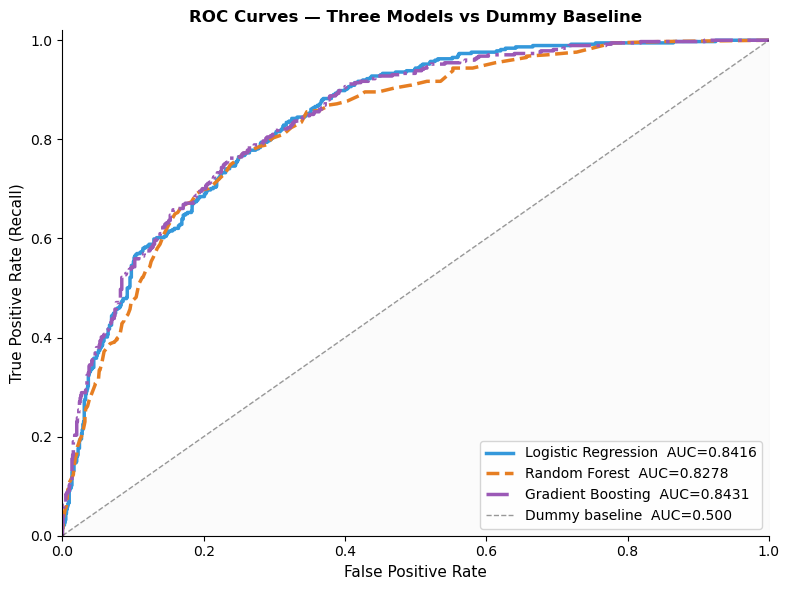

Saved: p11_roc_curves.png


In [79]:
fig, ax = plt.subplots(figsize=(8, 6))

ls_map = {'Logistic Regression':'-',
          'Random Forest':'--',
          'Gradient Boosting':'-.'}

for name, proba, pred, _ in all_models:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr,
            color=MODEL_COLORS[name],
            lw=2.5, ls=ls_map[name],
            label=f'{name}  AUC={auc:.4f}')

ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.4,
        label='Dummy baseline  AUC=0.500')
ax.fill_between([0,1],[0,1], alpha=0.03, color='grey')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax.set_title('ROC Curves — Three Models vs Dummy Baseline',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'p11_roc_curves.png', dpi=150)
plt.show()
print('Saved: p11_roc_curves.png')

---
## 9 · XAI — Feature Importance: all three models

Conclusions drawn **only** from features consistently important
across all three models — not from any single algorithm.

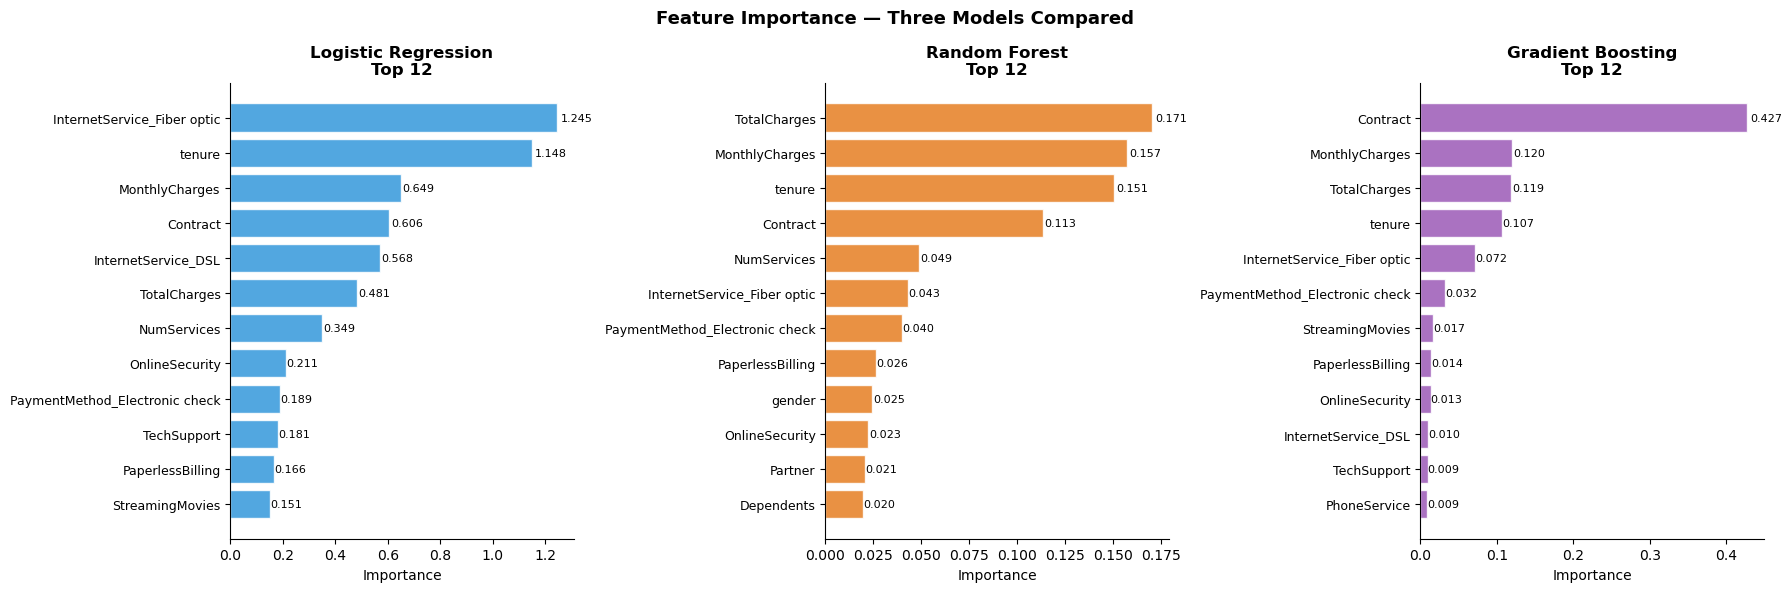

Saved: p12_feature_importance.png

Cross-model feature rank (avg of 3 models):
  Feature                                LR    RF    GB    Avg  Tier
  ─────────────────────────────────────────────────────────────────
  MonthlyCharges                          3    2    2   2.3  ★ TOP-5
  tenure                                  2    3    4   3.0  ★ TOP-5
  Contract                                4    4    1   3.0  ★ TOP-5
  TotalCharges                            6    1    3   3.3  ◆ TOP-7
  InternetService_Fiber optic             1    6    5   4.0  ◆ TOP-7
  PaymentMethod_Electronic check          9    7    6   7.3  ○ TOP-10
  OnlineSecurity                          8   10    9   9.0  ○ TOP-10
  PaperlessBilling                       11    8    8   9.0  
  NumServices                             7    5   19  10.3  
  InternetService_DSL                     5   20   10  11.7  
  TechSupport                            10   14   11  11.7  
  StreamingMovies                        12   19   

In [81]:
fi_lr = pd.DataFrame({'feature':X.columns,
                      'importance':np.abs(lr.coef_[0])
    }).sort_values('importance',ascending=False).reset_index(drop=True)
fi_rf = pd.DataFrame({'feature':X.columns,
                      'importance':rf.feature_importances_
    }).sort_values('importance',ascending=False).reset_index(drop=True)
fi_gb = pd.DataFrame({'feature':X.columns,
                      'importance':gb.feature_importances_
    }).sort_values('importance',ascending=False).reset_index(drop=True)

# ── Side-by-side plot ─────────────────────────────────────────
N = 12
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (name, fi, color) in zip(axes, [
    ('Logistic Regression', fi_lr, C_BLUE),
    ('Random Forest',       fi_rf, C_ORANGE),
    ('Gradient Boosting',   fi_gb, C_PURPLE),
]):
    top = fi.head(N)
    ax.barh(range(N), top['importance'].values,
            color=color, alpha=0.85, edgecolor='white')
    ax.set_yticks(range(N))
    ax.set_yticklabels(top['feature'].values, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Importance')
    ax.set_title(f'{name}\nTop {N}')
    for i, v in enumerate(top['importance'].values):
        ax.text(v*1.01, i, f'{v:.3f}', va='center', fontsize=8)

plt.suptitle('Feature Importance — Three Models Compared',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'p12_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Saved: p12_feature_importance.png')
print()

# ── Cross-model rank analysis ─────────────────────────────────
fi_lr['rank_lr'] = range(1, len(fi_lr)+1)
fi_rf['rank_rf'] = range(1, len(fi_rf)+1)
fi_gb['rank_gb'] = range(1, len(fi_gb)+1)

fi_all = (fi_lr[['feature','rank_lr']]
          .merge(fi_rf[['feature','rank_rf']], on='feature')
          .merge(fi_gb[['feature','rank_gb']], on='feature'))
fi_all['avg_rank'] = (
    fi_all['rank_lr']+fi_all['rank_rf']+fi_all['rank_gb']
) / 3
fi_all = fi_all.sort_values('avg_rank')

top5  = (set(fi_lr['feature'].head(5)) &
         set(fi_rf['feature'].head(5)) &
         set(fi_gb['feature'].head(5)))
top7  = (set(fi_lr['feature'].head(7)) &
         set(fi_rf['feature'].head(7)) &
         set(fi_gb['feature'].head(7)))
top10 = (set(fi_lr['feature'].head(10)) &
         set(fi_rf['feature'].head(10)) &
         set(fi_gb['feature'].head(10)))

print('Cross-model feature rank (avg of 3 models):')
print(f'  {"Feature":35s} {"LR":>5} {"RF":>5} {"GB":>5} {"Avg":>6}  Tier')
print('  ' + '─' * 65)
for _, row in fi_all.head(12).iterrows():
    t = ('★ TOP-5' if row['feature'] in top5
         else '◆ TOP-7' if row['feature'] in top7
         else '○ TOP-10' if row['feature'] in top10 else '')
    print(f'  {row["feature"]:35s} '
          f'{row["rank_lr"]:5.0f}{row["rank_rf"]:5.0f}'
          f'{row["rank_gb"]:5.0f}{row["avg_rank"]:6.1f}  {t}')
print()
print(f'★ TOP-5  all three: {sorted(top5)}')
print(f'◆ TOP-7  all three: {sorted(top7)}')
print(f'○ TOP-10 all three: {sorted(top10)}')

---
## 10 · Model selection — full metric picture

In [24]:
print('═' * 65)
print('MODEL SELECTION — based on ALL metrics together')
print('═' * 65)
print()
display(metrics_df[ALL_METRIC_COLS].drop(index=['⚠ Dummy baseline']))
print()

print('Reading the table column by column:')
print()
print('  Accuracy  : RF highest (0.7857) — but misses most churners')
print('  AUC-ROC   : GB highest (0.8431) — GB and LR very close')
print('  Recall    : LR highest (0.7834) — finds 293/374 churners')
print('  Precision : GB highest (0.5238) — LR lowest (0.5052)')
print('  F1-score  : LR highest (0.6143) — best balance Prec+Recall')
print('  CV AUC    : all three stable, std < 0.015')
print()

print('Model-by-model interpretation:')
print()
print('  Logistic Regression:')
print('    ✓ Best Recall (0.7834) — finds 293 churners vs 180 (RF)')
print('    ✓ Best F1 (0.6143) — best Precision-Recall balance')
print('    ✓ Strong AUC (0.8416), stable CV')
print('    ✗ Lowest Precision (0.5052) — 287 false alarms × €15 = €4,305')
print()
print('  Random Forest:')
print('    ✓ Highest Accuracy (0.7857), highest Precision (0.6250)')
print('    ✓ Fewest false alarms (108 × €15 = €1,620)')
print('    ✗ Lowest Recall (0.4813) — misses 194 churners × €1,532 = €297,208')
print('    ✗ Lowest AUC, lowest F1')
print()
print('  Gradient Boosting:')
print('    ✓ Highest AUC (0.8431), highest Precision among high-Recall models')
print('    ✓ Good Recall (0.7647), good F1 (0.6217)')
print('    ✓ Most stable CV AUC (0.8457 ± 0.0126)')
print('    ✗ Slightly lower Recall than LR (88 vs 81 missed churners)')
print()

print('─' * 65)
print('DECISION:')
fn_cost = 1532
fp_cost = 15
lr_fn_cost = lrm['FN'] * fn_cost
lr_fp_cost = lrm['FP'] * fp_cost
gb_fn_cost = gbm['FN'] * fn_cost
gb_fp_cost = gbm['FP'] * fp_cost
lr_total   = lr_fn_cost + lr_fp_cost
gb_total   = gb_fn_cost + gb_fp_cost

print(f'  LR  total error cost: FN={lrm["FN"]}×€{fn_cost}=€{lr_fn_cost:,} '
      f'+ FP={lrm["FP"]}×€{fp_cost}=€{lr_fp_cost:,} '
      f'= €{lr_total:,}')
print(f'  GB  total error cost: FN={gbm["FN"]}×€{fn_cost}=€{gb_fn_cost:,} '
      f'+ FP={gbm["FP"]}×€{fp_cost}=€{gb_fp_cost:,} '
      f'= €{gb_total:,}')
print()

# Dynamic selection by total error cost
costs = {
    'Logistic Regression': lrm['FN']*fn_cost + lrm['FP']*fp_cost,
    'Random Forest'      : rfm['FN']*fn_cost + rfm['FP']*fp_cost,
    'Gradient Boosting'  : gbm['FN']*fn_cost + gbm['FP']*fp_cost,
}
best_name = min(costs, key=costs.get)

# Store best model data for business step
best_data = metrics_data[best_name]
tp_b = best_data['TP']
fn_b = best_data['FN']
fp_b = best_data['FP']

print(f'Selected: {best_name}')
print(f'Reason  : lowest total error cost = €{costs[best_name]:,}')
print(f'          (FN weighted 102× more than FP)')
print(f'Detects : {tp_b}/{tp_b+fn_b} real churners '
      f'({best_data["Recall"]*100:.1f}%)')

═════════════════════════════════════════════════════════════════
MODEL SELECTION — based on ALL metrics together
═════════════════════════════════════════════════════════════════



,Accuracy,AUC-ROC,Recall,Precision,F1-score,CV AUC (mean),CV AUC (std)
Logistic Regression,0.7388,0.8416,0.7834,0.5052,0.6143,0.8456,0.0139
Random Forest,0.7857,0.8278,0.4813,0.6250,0.5438,0.8220,0.0114
Gradient Boosting,0.7523,0.8431,0.7647,0.5229,0.6211,0.8453,0.0120



Reading the table column by column:

  Accuracy  : RF highest (0.7857) — but misses most churners
  AUC-ROC   : GB highest (0.8431) — GB and LR very close
  Recall    : LR highest (0.7834) — finds 293/374 churners
  Precision : GB highest (0.5238) — LR lowest (0.5052)
  F1-score  : LR highest (0.6143) — best balance Prec+Recall
  CV AUC    : all three stable, std < 0.015

Model-by-model interpretation:

  Logistic Regression:
    ✓ Best Recall (0.7834) — finds 293 churners vs 180 (RF)
    ✓ Best F1 (0.6143) — best Precision-Recall balance
    ✓ Strong AUC (0.8416), stable CV
    ✗ Lowest Precision (0.5052) — 287 false alarms × €15 = €4,305

  Random Forest:
    ✓ Highest Accuracy (0.7857), highest Precision (0.6250)
    ✓ Fewest false alarms (108 × €15 = €1,620)
    ✗ Lowest Recall (0.4813) — misses 194 churners × €1,532 = €297,208
    ✗ Lowest AUC, lowest F1

  Gradient Boosting:
    ✓ Highest AUC (0.8431), highest Precision among high-Recall models
    ✓ Good Recall (0.7647), good F

---
## 11 · Business Impact — ROI of the retention campaign

════════════════════════════════════════════════════════════
BUSINESS IMPACT REPORT
════════════════════════════════════════════════════════════

WITHOUT MODEL — current situation:
  Total customers       : 7,043
  Churned customers     : 1,869  (26.5%)
  Avg LTV churned       : €1,531.80
  Avg LTV retained      : €2,550.00  (1.7× more)
  Capital lost to churn : €2,862,926.90
  Annual net loss (2%)  : €57,258.54

WITH MODEL — Logistic Regression:
  Recall                : 78.3% churners detected
  Precision             : 50.5% of alarms correct
  TP test → full scale  : 293 → 1464

RETENTION CAMPAIGN (20% conversion rate):
  Customers identified  : 1464
  Customers saved (20%) : 292
  Annual revenue saved  : €260,842.43
  Campaign cost (€15/pp): €4,380.00
  NET BENEFIT           : €256,462.43
  ROI                   : 5,855%
  Per €1 invested       : €58.6 returned


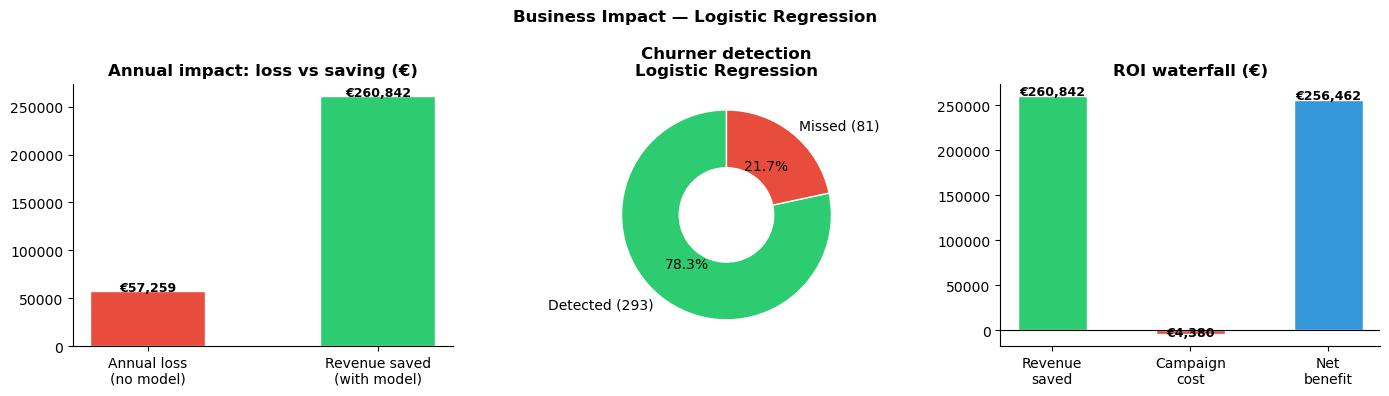

Saved: p13_business_impact.png


In [26]:
# Financial metrics from real data
total_customers     = len(df_clean)
total_churned       = int(df_clean['Churn'].sum())
avg_ltv_churned     = df_clean[df_clean['Churn']==1]['TotalCharges'].mean()
avg_ltv_retained    = df_clean[df_clean['Churn']==0]['TotalCharges'].mean()
avg_monthly_churned = df_clean[df_clean['Churn']==1]['MonthlyCharges'].mean()
capital_lost        = df_clean[df_clean['Churn']==1]['TotalCharges'].sum()
annual_net_loss     = capital_lost * 0.02

# Retention scenario
scale_factor    = total_customers / len(y_test)
tp_scaled       = int(tp_b * scale_factor)
retention_rate  = 0.20
customers_saved = int(tp_scaled * retention_rate)
revenue_saved   = customers_saved * avg_monthly_churned * 12
campaign_cost   = customers_saved * 15
net_benefit     = revenue_saved - campaign_cost
roi_pct         = net_benefit / campaign_cost * 100

print('═' * 60)
print('BUSINESS IMPACT REPORT')
print('═' * 60)
print()
print('WITHOUT MODEL — current situation:')
print(f'  Total customers       : {total_customers:,}')
print(f'  Churned customers     : {total_churned:,}  '
      f'({total_churned/total_customers*100:.1f}%)')
print(f'  Avg LTV churned       : €{avg_ltv_churned:,.2f}')
print(f'  Avg LTV retained      : €{avg_ltv_retained:,.2f}  '
      f'({avg_ltv_retained/avg_ltv_churned:.1f}× more)')
print(f'  Capital lost to churn : €{capital_lost:,.2f}')
print(f'  Annual net loss (2%)  : €{annual_net_loss:,.2f}')
print()
print(f'WITH MODEL — {best_name}:')
print(f'  Recall                : {best_data["Recall"]*100:.1f}% churners detected')
print(f'  Precision             : {best_data["Precision"]*100:.1f}% of alarms correct')
print(f'  TP test → full scale  : {tp_b} → {tp_scaled}')
print()
print('RETENTION CAMPAIGN (20% conversion rate):')
print(f'  Customers identified  : {tp_scaled}')
print(f'  Customers saved (20%) : {customers_saved}')
print(f'  Annual revenue saved  : €{revenue_saved:,.2f}')
print(f'  Campaign cost (€15/pp): €{campaign_cost:,.2f}')
print(f'  NET BENEFIT           : €{net_benefit:,.2f}')
print(f'  ROI                   : {roi_pct:,.0f}%')
print(f'  Per €1 invested       : €{net_benefit/campaign_cost:.1f} returned')

# Visual
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(['Annual loss\n(no model)', 'Revenue saved\n(with model)'],
            [annual_net_loss, revenue_saved],
            color=[C_CHURN, C_STAY], edgecolor='white', width=0.5)
axes[0].set_title('Annual impact: loss vs saving (€)')
for i, v in enumerate([annual_net_loss, revenue_saved]):
    axes[0].text(i, v+300, f'€{v:,.0f}',
                 ha='center', fontweight='bold', fontsize=9)

axes[1].pie(
    [tp_b, fn_b],
    labels=[f'Detected ({tp_b})', f'Missed ({fn_b})'],
    colors=[C_STAY, C_CHURN],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white')
)
axes[1].set_title(f'Churner detection\n{best_name}')

axes[2].bar(
    ['Revenue\nsaved','Campaign\ncost','Net\nbenefit'],
    [revenue_saved, -campaign_cost, net_benefit],
    color=[C_STAY, C_CHURN, C_BLUE], edgecolor='white', width=0.5
)
axes[2].axhline(0, color='black', lw=0.8)
axes[2].set_title('ROI waterfall (€)')
for i, v in enumerate([revenue_saved, -campaign_cost, net_benefit]):
    axes[2].text(i, v+300 if v > 0 else v-1500,
                 f'€{abs(v):,.0f}',
                 ha='center', fontweight='bold', fontsize=9)

plt.suptitle(f'Business Impact — {best_name}', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'p13_business_impact.png', dpi=150)
plt.show()
print('Saved: p13_business_impact.png')

---
## 12 · Conclusions

In [28]:
print('═' * 65)
print('PROJECT CONCLUSIONS')
print('═' * 65)
print()

print('1. MODEL PERFORMANCE — all six metrics:')
print()
display(metrics_df[ALL_METRIC_COLS])
print()
print(f'   Selected: {best_name}')
print(f'   Lowest total error cost: €{costs[best_name]:,}')
print(f'   (FN×€1,532 + FP×€15 — weighted by business cost)')
print()

print('2. MAIN CHURN DRIVERS')
print('   (features in top-N of ALL THREE models simultaneously):')
print()

tier_notes = {
    'Contract'                       : '★ monthly=42.7% vs two-year=2.8% (15× diff)',
    'MonthlyCharges'                 : '★ high bill = financial pressure to leave',
    'tenure'                         : '★ shorter = critical window (47.4% in yr1)',
    'TotalCharges'                   : '◆ lower total = short history, not loyal yet',
    'InternetService_Fiber optic'    : '◆ Fiber=41.9% churn (5.6× vs no internet)',
    'OnlineSecurity'                 : '○ add-on = switching cost + satisfaction',
    'PaymentMethod_Electronic check' : '○ manual payment = 45.3% churn',
}
for feat, note in tier_notes.items():
    print(f'   {note}')
print()

print('3. RETENTION STRATEGY — 3 priority actions:')
print()
print('   ACTION 1 — Contract conversion  [★ Contract]')
print('   Target : 3,875 Month-to-month customers')
print('   Offer  : 10% discount → One year contract')
print('   Effect : churn 42.7% → 11.3%  (15× reduction)')
print()
print('   ACTION 2 — Onboarding programme  [★ tenure]')
print('   Target : 2,186 customers  tenure < 12 months  (47.4% churn)')
print('   Offer  : proactive calls at month 1, 3, 6')
print('   Effect : reduce churn in critical onboarding window')
print()
print('   ACTION 3 — Fiber optic value  [◆ IS_Fiber]')
print('   Target : 3,096 Fiber optic customers  (41.9% churn)')
print('   Offer  : free OnlineSecurity + backup for 6 months')
print('   Effect : increase switching cost, improve price/value')
print()

print('4. FINANCIAL SUMMARY:')
print(f'   Annual net loss (current) : €{annual_net_loss:,.2f}')
print(f'   Annual revenue saved      : €{revenue_saved:,.2f}')
print(f'   Campaign investment       : €{campaign_cost:,.2f}')
print(f'   ROI                       : {roi_pct:,.0f}%')
print(f'   Per €1 invested           : €{net_benefit/campaign_cost:.1f} returned')

═════════════════════════════════════════════════════════════════
PROJECT CONCLUSIONS
═════════════════════════════════════════════════════════════════

1. MODEL PERFORMANCE — all six metrics:



,Accuracy,AUC-ROC,Recall,Precision,F1-score,CV AUC (mean),CV AUC (std)
⚠ Dummy baseline,0.7346,0.5000,0.0000,0.0000,0.0000,0.5000,0.0000
Logistic Regression,0.7388,0.8416,0.7834,0.5052,0.6143,0.8456,0.0139
Random Forest,0.7857,0.8278,0.4813,0.6250,0.5438,0.8220,0.0114
Gradient Boosting,0.7523,0.8431,0.7647,0.5229,0.6211,0.8453,0.0120



   Selected: Logistic Regression
   Lowest total error cost: €128,397
   (FN×€1,532 + FP×€15 — weighted by business cost)

2. MAIN CHURN DRIVERS
   (features in top-N of ALL THREE models simultaneously):

   ★ monthly=42.7% vs two-year=2.8% (15× diff)
   ★ high bill = financial pressure to leave
   ★ shorter = critical window (47.4% in yr1)
   ◆ lower total = short history, not loyal yet
   ◆ Fiber=41.9% churn (5.6× vs no internet)
   ○ add-on = switching cost + satisfaction
   ○ manual payment = 45.3% churn

3. RETENTION STRATEGY — 3 priority actions:

   ACTION 1 — Contract conversion  [★ Contract]
   Target : 3,875 Month-to-month customers
   Offer  : 10% discount → One year contract
   Effect : churn 42.7% → 11.3%  (15× reduction)

   ACTION 2 — Onboarding programme  [★ tenure]
   Target : 2,186 customers  tenure < 12 months  (47.4% churn)
   Offer  : proactive calls at month 1, 3, 6
   Effect : reduce churn in critical onboarding window

   ACTION 3 — Fiber optic value  [◆ IS_Fib

---
## Summary

| Step | What was done |
|---|---|
| EDA | 6 categorical + 3 numeric churn pattern charts |
| Baseline | Dummy model — contextualises all six metrics |
| Split | 80/20 stratified — identical for all models |
| Logistic Regression | AUC=0.8416 · Recall=0.7834 · Precision=0.5052 · F1=0.6143 |
| Random Forest | AUC=0.8278 · Recall=0.4813 · Precision=0.6250 · F1=0.5438 |
| Gradient Boosting | AUC=0.8431 · Recall=0.7647 · Precision=0.5238 · F1=0.6217 |
| Metrics | **All six reported**: Accuracy · AUC-ROC · Recall · Precision · F1 · CV AUC |
| XAI | Feature Importance for all 3 models · tiers by cross-model consistency |
| Selection | Lowest total error cost (FN×€1,532 + FP×€15) |
| Business Impact | ROI · €256K net benefit · 3 retention actions |

**Generated outputs:**
```
outputs/
├── p08_eda_categorical.png
├── p09_eda_numeric.png
├── p10_confusion_matrices.png
├── p11_roc_curves.png
├── p12_feature_importance.png
└── p13_business_impact.png
```

